# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

Business Questions that will be answered below:
1. How many customers were there for each approach?
2. What does the spread of the revenue look like overall? And for each method?
3. Was there any difference in revenue over time for each of the methods?
4. Based on the data, which method would you recommend we continue to use? Some of these methods take more time from the team so they may not be the best for use to use if the results are similar.

**I. Data Validation**

In [73]:
# Importing needed modules and the data
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

product_sales = pd.read_csv('product_sales.csv')
product_sales.head(10)

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois
5,6,Call,6489e678-40f2-4fed-a48e-d0dff9c09205,13,65.01,10,24,Mississippi
6,4,Email,eb6bd5f1-f115-4e4b-80a6-5e67fcfbfb94,11,113.38,9,28,Georgia
7,1,Email,047df079-071b-4380-9012-2bfe9bce45d5,10,99.94,1,22,Oklahoma
8,5,Email,771586bd-7b64-40be-87df-afe884d2af9e,11,108.34,10,31,Massachusetts
9,5,Call,56491dae-bbe7-49f0-a651-b823a01103d8,11,53.82,7,23,Missouri


In [74]:
# Assigning the raw data
df = product_sales.copy()

**A. Checking the Data**

In [75]:
# Checking for missing values and the data type for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            13926 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB


There are some missing values in the revenue column.

In [76]:
# 1. Checking the missing values
df.isna().sum()

week                    0
sales_method            0
customer_id             0
nb_sold                 0
revenue              1074
years_as_customer       0
nb_site_visits          0
state                   0
dtype: int64

As indicated above, there are 1074 missing values in the revenue column.

In [77]:
# 2. Data Validation: Checking if the unique values are correct
df.nunique()

week                     6
sales_method             5
customer_id          15000
nb_sold                 10
revenue               6743
years_as_customer       42
nb_site_visits          27
state                   50
dtype: int64

The sales_method column should have 3 types of methods; instead, it has 5 types of methods. 

In [78]:
# 3. Checking outliers using the summary statistics
df.describe()

,week,nb_sold,revenue,years_as_customer,nb_site_visits
count,15000.000000,15000.000000,13926.000000,15000.000000,15000.000000
mean,3.098267,10.084667,93.934943,4.965933,24.990867
std,1.656420,1.812213,47.435312,5.044952,3.500914
min,1.000000,7.000000,32.540000,0.000000,12.000000
25%,2.000000,9.000000,52.470000,1.000000,23.000000
50%,3.000000,10.000000,89.500000,3.000000,25.000000
75%,5.000000,11.000000,107.327500,7.000000,27.000000
max,6.000000,16.000000,238.320000,63.000000,41.000000


Looking at the years_as_customer column, the max is 63 years, which contradicts the founding of the company. The company was founded around 1984, and as such, it is impossible for a customer to hold 63 years as a customer.

In [79]:
# Proportion of missing values relative to the total entries in the revenue column
(df['revenue'].isna().sum() / df['revenue'].count()) * 100

7.7121930202498925

There is 7.7% of missing data in the revenue column. The missing data cannot be dropped unless they are Missing Completely at Random (MCAR) or Missing at Random (MAR). However, if the data is examined and it is Missing Not at Random (MNAR), dropping the missing values can introduce bias into the data. 

**B. Handling the Data**

1. Handling sales_method column - should have 3 unique values

In [80]:
# The sales_method column should have 3 unique values
df['sales_method'].unique()

array(['Email', 'Email + Call', 'Call', 'em + call', 'email'],
      dtype=object)

In [81]:
# Standardizing the values in the sales_method column by replacing 'em + call' with 'Email + Call' and 'email' with 'Email'

# First, create a copy of the original DataFrame
df_corrected = df.copy()

# Replacing the values in the sales_method column
df_corrected['sales_method'] = df['sales_method'].replace({'em + call': 'Email + Call', 'email': 'Email'})

# Checking if the replacement is applied
unique_sales_method = df_corrected['sales_method'].unique()
print("Unique values in the sales_method after replacement:", unique_sales_method)

Unique values in the sales_method after replacement: ['Email' 'Email + Call' 'Call']


2. Handling the outliers in years_as_customer column

In [82]:
# If values are greater than 40 in years_as_customer, these values are considered as outliers
df_corrected[df_corrected['years_as_customer'] > 40]

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
13741,2,Email,18919515-a618-430c-9a05-2c7d8fea96af,10,97.22,63,24,California
13800,4,Call,2ea97d34-571d-4e1b-95be-fea1c404649f,10,50.47,47,27,California


In [83]:
# As there are only two records of years_as_customer that are considered outliers, we can drop them

# Filtering the records where years_as_customer is less than or equal to 40
df_filtered = df_corrected[df_corrected['years_as_customer'] <= 40]

# Checking the number of records before and after filtering
print("Number of records before filtering:", len(df_corrected))
print("Number of records after filtering:", len(df_filtered))

Number of records before filtering: 15000
Number of records after filtering: 14998


3. Handling missing values in the revenue column
First, a statistical test needs to be conducted to determine if there is a relationship between the missing values in the 'revenue' column and the 'sales_method' column. The chi-square test of independence is appropriate when both variables are categorical. As such, the 'revenue' column needs to be converted into a category.

In [84]:
# Replacing NaN values with "Null" and non-NaN values with "Not_Null"
df_filtered['revenue_category'] = df_filtered['revenue'].fillna('Null').map(lambda x: 'Not_Null' if x != 'Null' else x)

# Checking the unique vales in the revenue_category column
unique_revenue_category = df_filtered['revenue_category'].unique()
print("Unique values in the revenue_category column:", unique_revenue_category)

Unique values in the revenue_category column: ['Null' 'Not_Null']


In [85]:
# Checking the overview of the filtered data
df_filtered.head()

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state,revenue_category
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona,Null
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas,Not_Null
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin,Not_Null
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana,Null
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois,Not_Null


Next, a contingency table needs to be created first to have the needed frequencies of each combination of the 'sales_method' and 'revenue_category' columns before conducting the chi-square test of independence. Then afterwards, the chi2_contingency from the scipy.stats module to perform the chi-square test of independence. 

In [86]:
from scipy.stats import chi2_contingency

# Creating a contingency table
contingency_table = pd.crosstab(df_filtered['sales_method'], df_filtered['revenue_category'])

# Printing the contingency table
print("Contingency Table:")
print(contingency_table)

# Perform the chi-square test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

# Printing the results
print("\nChi-square statistic:", chi2)
print("p-value:", p_value)

# Interpret the results

# Significance Level:
alpha = 0.05
if p_value < alpha:
    print("\nThere is a significant relationship between 'sales_method' and 'revenue_category'.")
else:
    print("\nThere is no significant relationship between 'sales_method' and 'revenue_category'.")

Contingency Table:
revenue_category  Not_Null  Null
sales_method                    
Call                  4780   181
Email                 6921   544
Email + Call          2223   349

Chi-square statistic: 251.11783987671868
p-value: 2.954295391738752e-55

There is a significant relationship between 'sales_method' and 'revenue_category'.


As there is a significant relationship between 'sales_method' and 'revenue_category', the missing values cannot easily be dropped. Thus, dropping the missing values can introduce bias into the analysis.

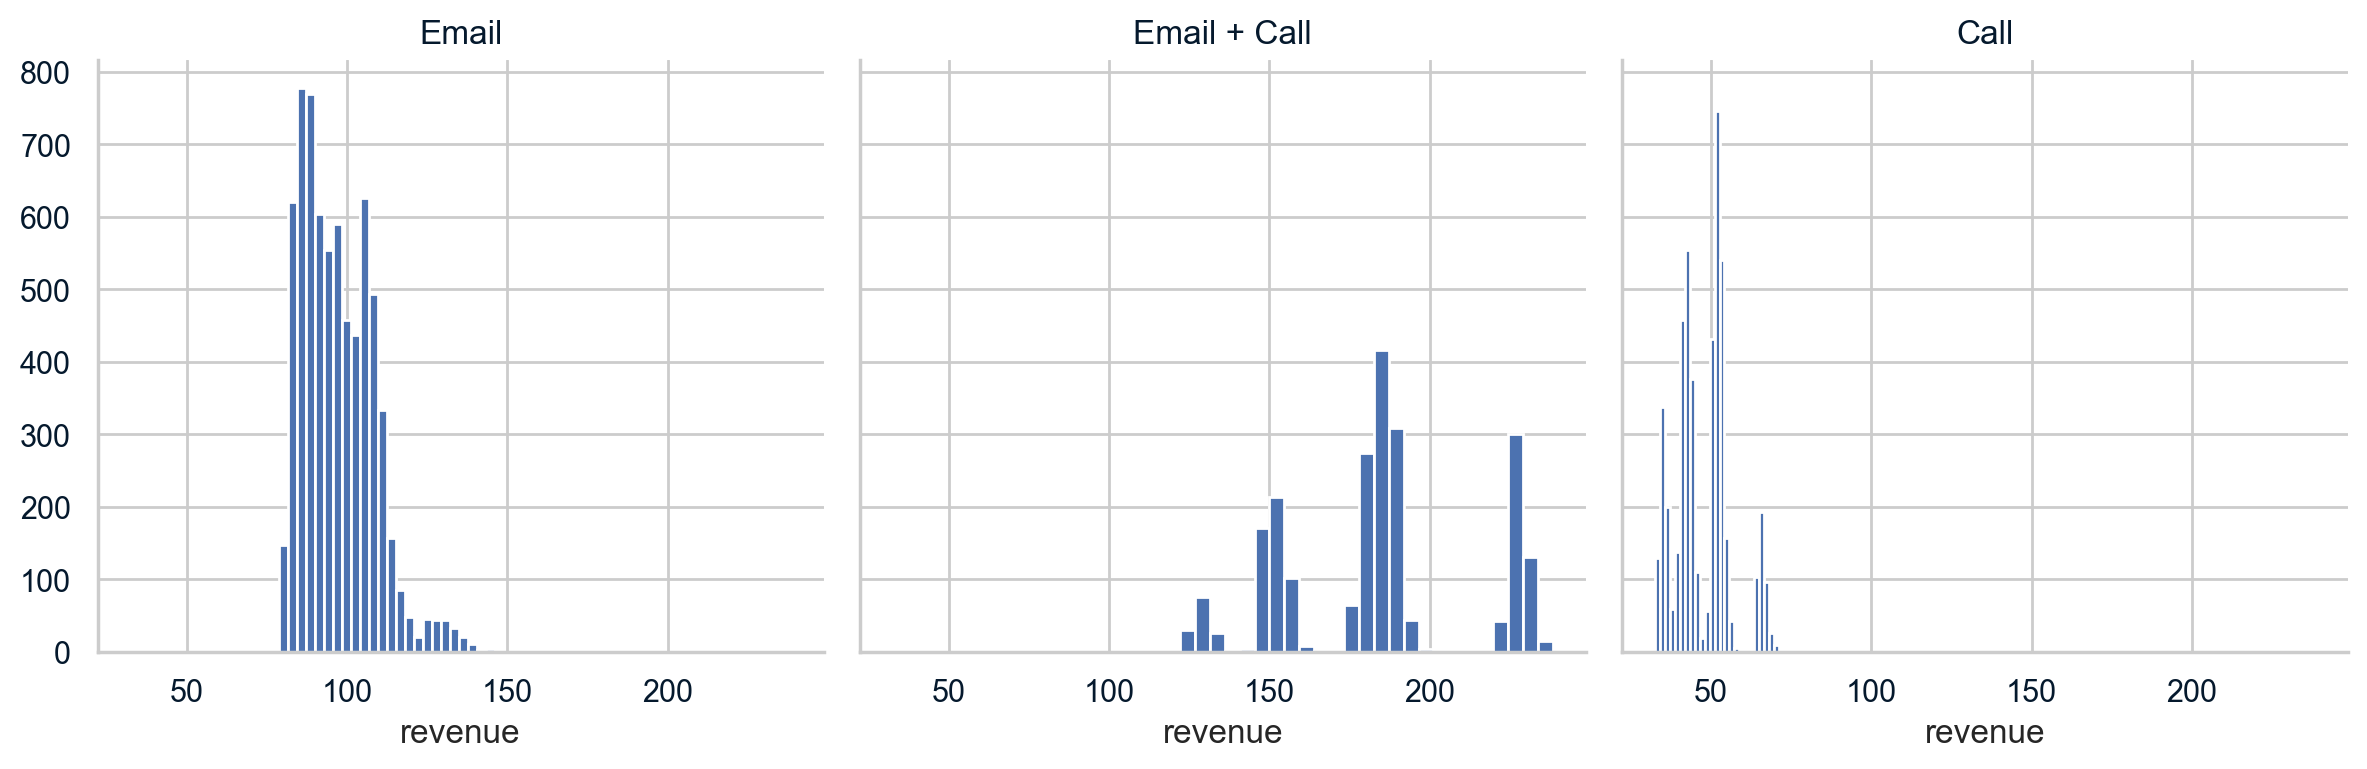

In [87]:
# Visualizing to identify which statistic to use for imputation
import seaborn as sns
import matplotlib.pyplot as plt

# Setting the style of seaborn
sns.set(style="whitegrid")

# Creating a facet grid
g = sns.FacetGrid(df_filtered, col="sales_method", col_wrap=3, height=4)

# Mapping a histogram for 'revenue' onto the grid
g.map(plt.hist, "revenue", bins=25)

# Adding titles
g.set_titles("{col_name}")

# Adjusting layout
plt.tight_layout()

# Showing the plot
plt.show()

As the distribution of revenue for each sales method is not normal, the median is the best statistic to use for imputation. 

In [88]:
# Function to use for stratified imputation
def stratified_imputation(group):
    # Calculating the median of 'revenue' within each group
    median_revenue = group['revenue'].median()
    # Imputing missing values with the median within each group
    group['revenue'] = group['revenue'].fillna(median_revenue)

    return group

# Grouping the DataFrame by 'sales_method' and applying stratified imputation
df_imputed = df_filtered.groupby('sales_method').apply(stratified_imputation)

# Checking if there are still missing values in the 'revenue' column
missing_values = df_imputed['revenue'].isnull().sum()
print("Number of missing values after imputation:", missing_values)

Number of missing values after imputation: 0


In [89]:
# Assigning the filtered and imputed dataset
df = df_imputed.reset_index()

df.head(15)

,index,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state,revenue_category
0,0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,95.58,0,24,Arizona,Null
1,1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas,Not_Null
2,2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin,Not_Null
3,3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,95.58,3,25,Indiana,Null
4,4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois,Not_Null
5,5,6,Call,6489e678-40f2-4fed-a48e-d0dff9c09205,13,65.01,10,24,Mississippi,Not_Null
6,6,4,Email,eb6bd5f1-f115-4e4b-80a6-5e67fcfbfb94,11,113.38,9,28,Georgia,Not_Null
7,7,1,Email,047df079-071b-4380-9012-2bfe9bce45d5,10,99.94,1,22,Oklahoma,Not_Null
8,8,5,Email,771586bd-7b64-40be-87df-afe884d2af9e,11,108.34,10,31,Massachusetts,Not_Null
9,9,5,Call,56491dae-bbe7-49f0-a651-b823a01103d8,11,53.82,7,23,Missouri,Not_Null


**II. Exploratory Data Analysis**

In [90]:
# Assigning the data
eda = df.copy()

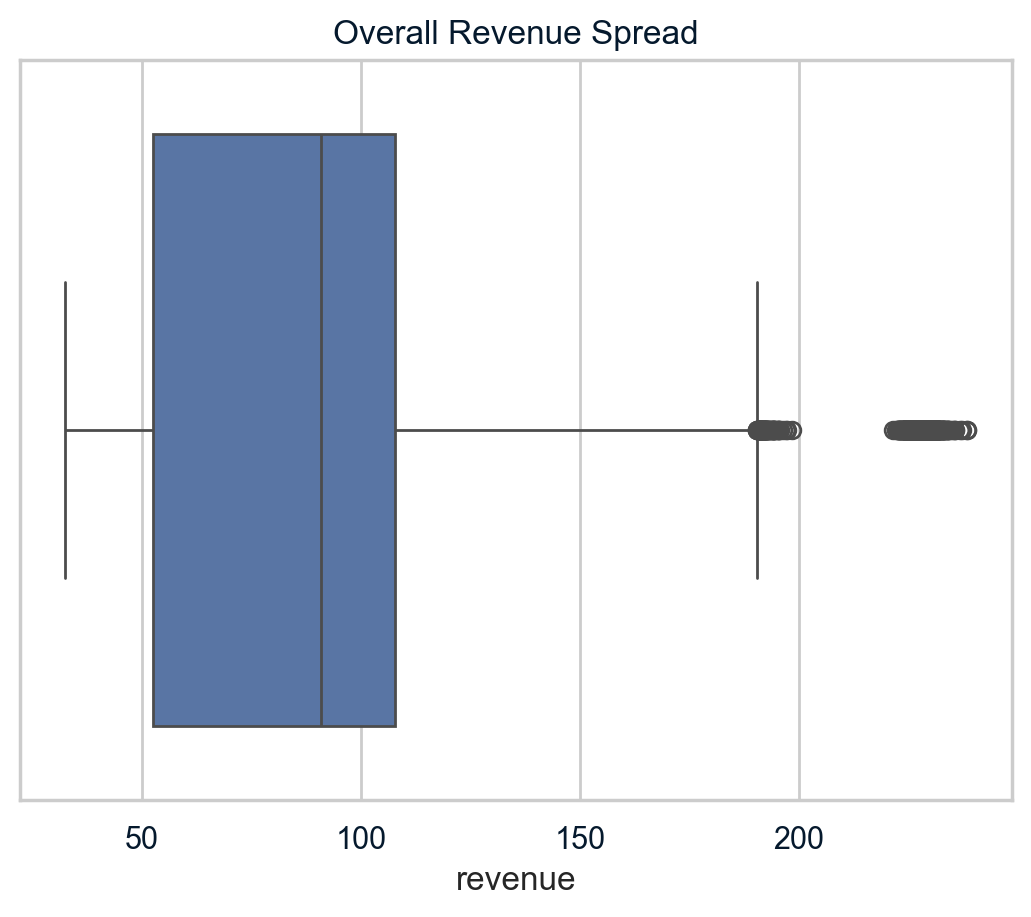

In [91]:
# Checking the Overall Revenue
sns.boxplot(data=eda, x='revenue')
plt.title('Overall Revenue Spread')
plt.xlabel('revenue')
plt.show()

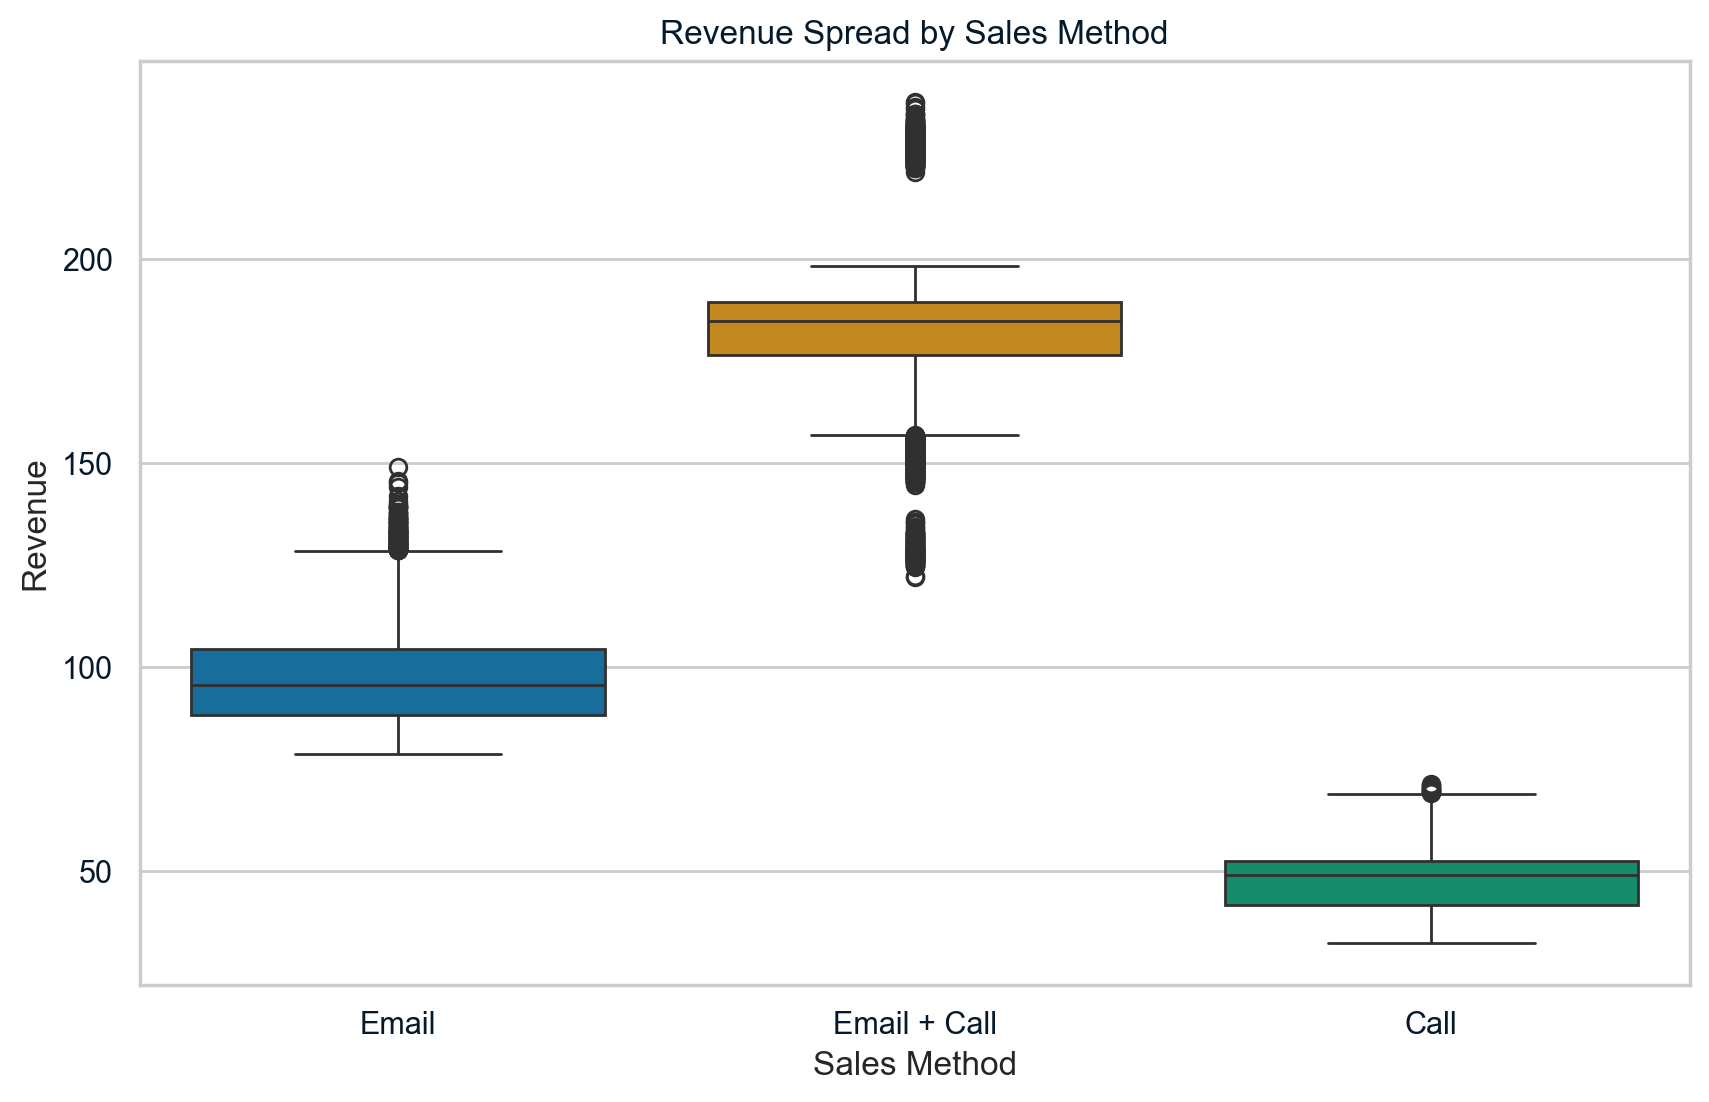

In [92]:
# Checking the revenue spread for each sales method
plt.figure(figsize=(10, 6))
sns.boxplot(data=eda, x='sales_method', y='revenue', hue='sales_method', palette='colorblind')
plt.title('Revenue Spread by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Revenue')
plt.show()

sales_method
Call             49.05
Email            95.58
Email + Call    184.74
Name: revenue, dtype: float64


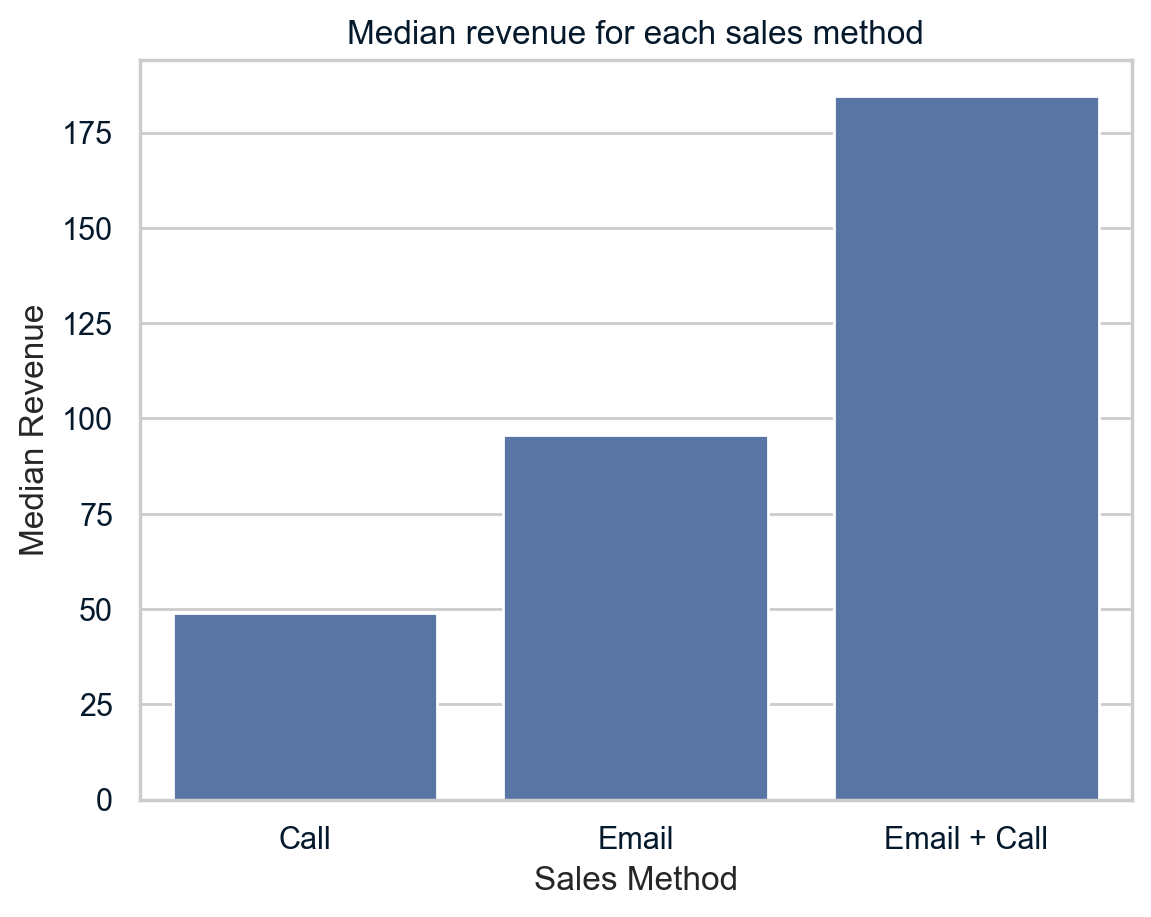

In [93]:
# Checking the median revenue for each sales method
median_df = eda.groupby('sales_method')['revenue'].median()
print(median_df)

# Visualizing the median_df
sns.barplot(data=median_df)
plt.title('Median revenue for each sales method')
plt.xlabel('Sales Method')
plt.ylabel('Median Revenue')
plt.show()

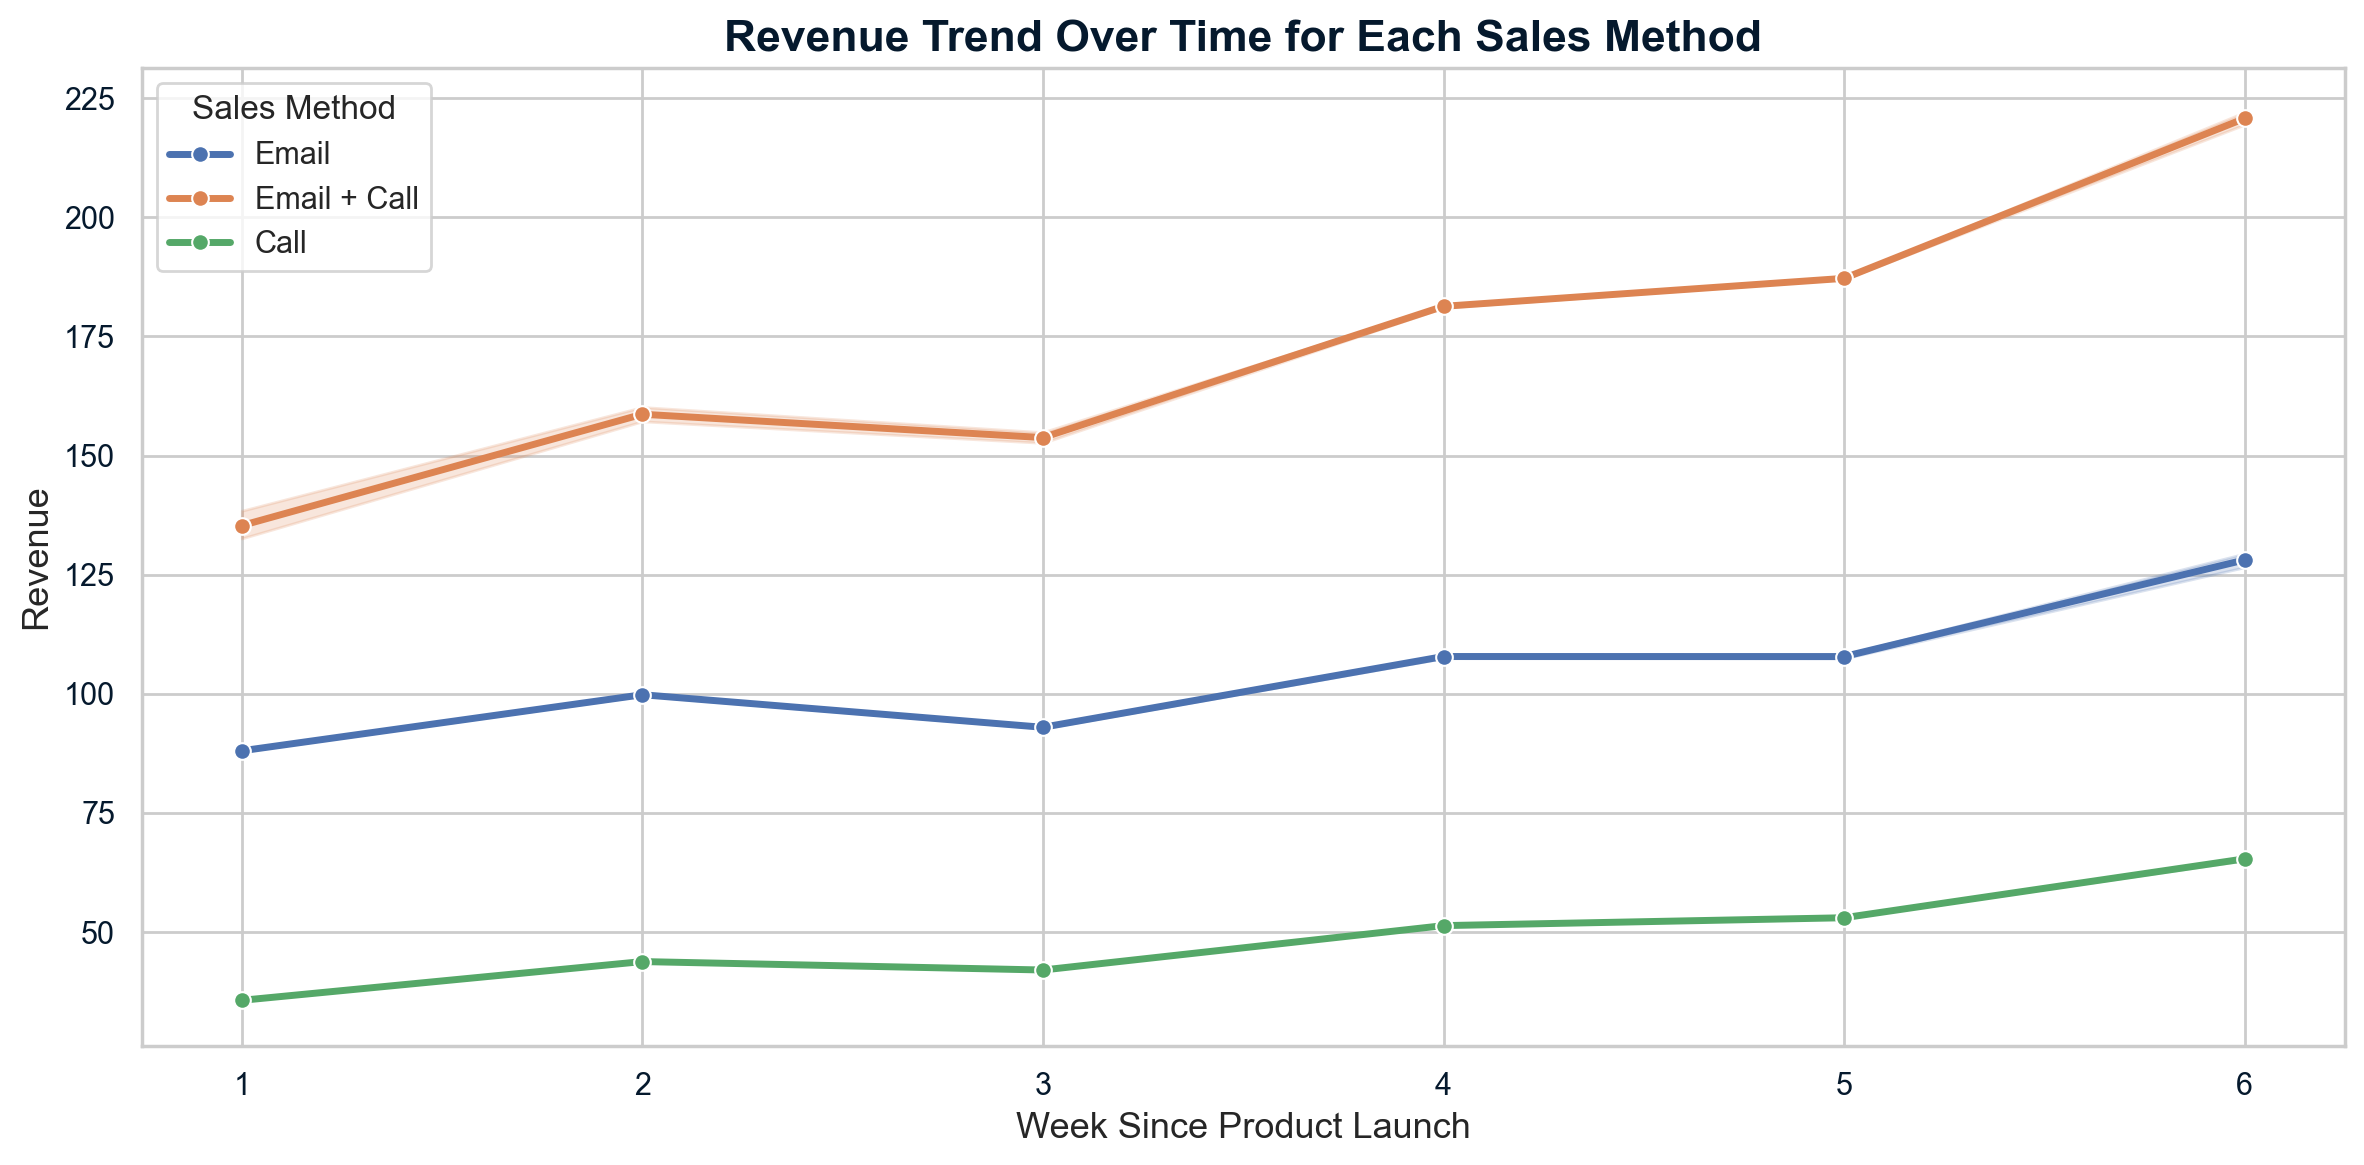

In [94]:
# Analyzing the difference in revenue over time for each sales method using line plots to show the trend of revenue over the weeks since the product launch

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=eda,
    x='week',
    y='revenue',
    hue='sales_method',
    marker='o',
    linewidth=2.5
)

plt.title('Revenue Trend Over Time for Each Sales Method', fontsize=16, fontweight='bold')
plt.xlabel('Week Since Product Launch', fontsize=13)
plt.ylabel('Revenue', fontsize=13)
plt.legend(title='Sales Method', title_fontsize='12', fontsize='11')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

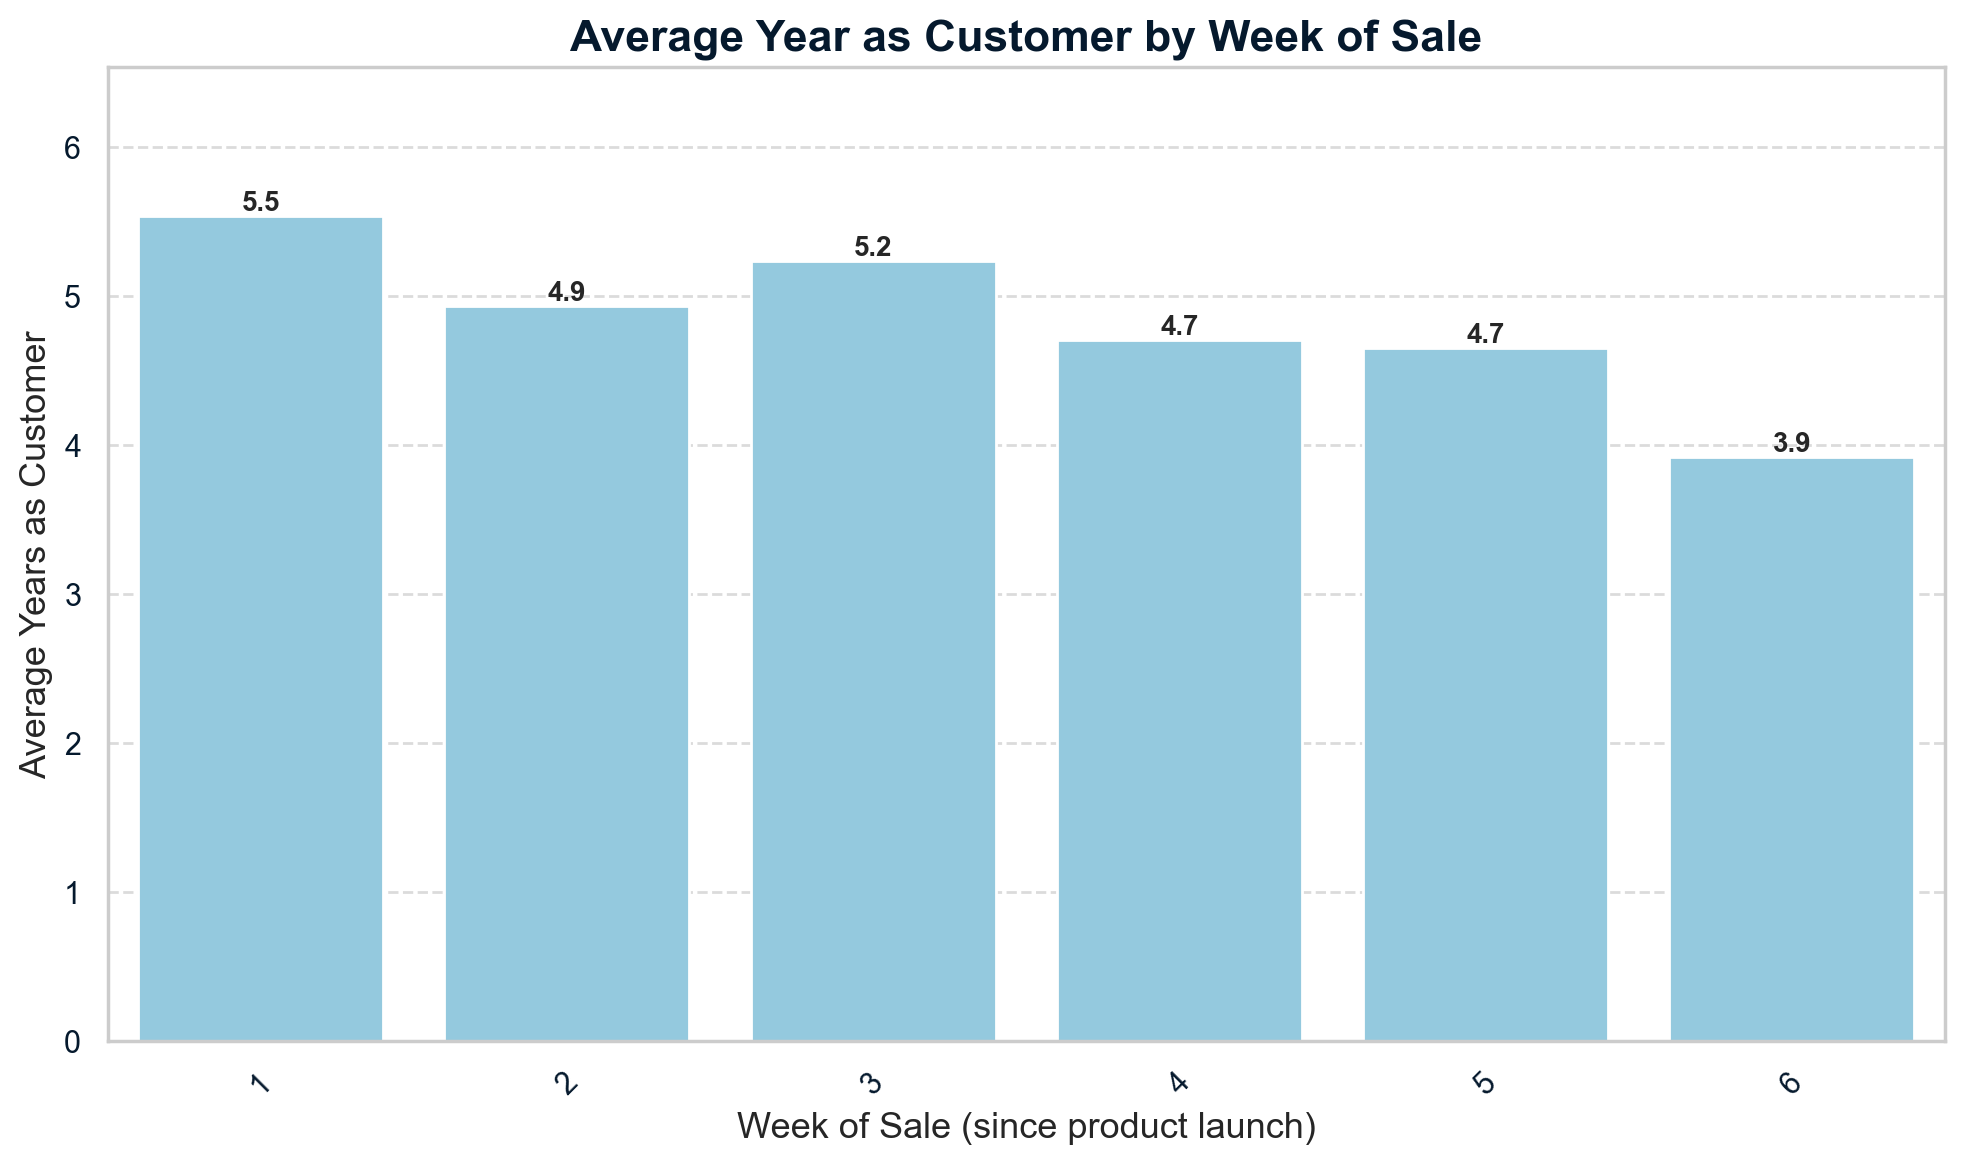

In [95]:
# Recalculating the data
avg_years_by_week = eda.groupby('week').years_as_customer.mean().reset_index()
sns.set_style("whitegrid")

# Plotting
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=avg_years_by_week, x='week', y='years_as_customer', color='skyblue')
for bar in barplot.patches:
    height = bar.get_height()
    barplot.annotate(f'{height:.1f}',
                    (bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

plt.title('Average Year as Customer by Week of Sale', fontsize=16, fontweight='bold')
plt.xlabel('Week of Sale (since product launch)', fontsize=13)
plt.ylabel('Average Years as Customer', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(0, avg_years_by_week['years_as_customer'].max() + 1)

plt.tight_layout()
plt.show()

In [96]:
# Calculating the correlation between week and years_as_customer
correlation = eda.week.corr(eda.years_as_customer)
print("Correlation between week and years_as_customer:", correlation)

Correlation between week and years_as_customer: -0.08268829695786738


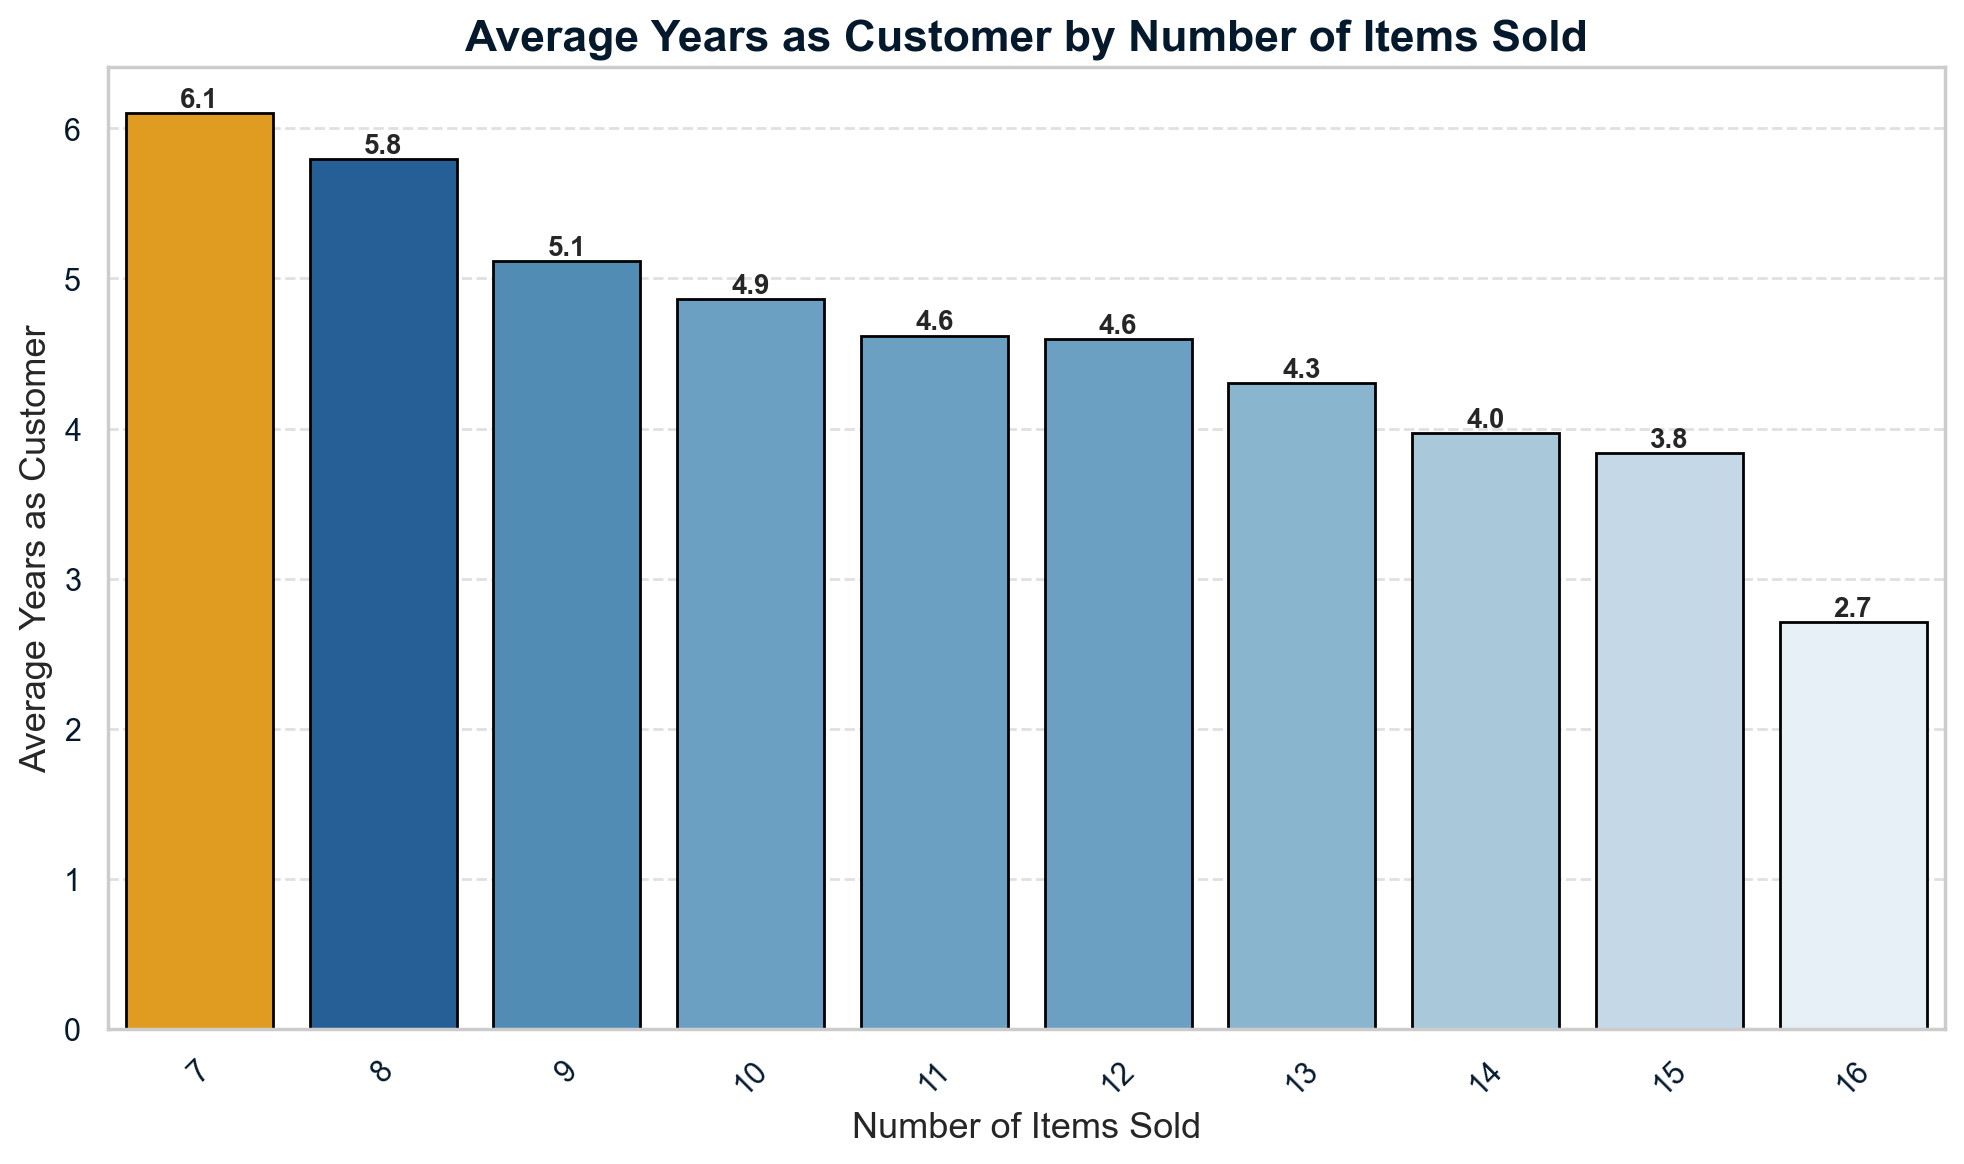

In [97]:
# Calculating the average years as customer for each nb_sold group

import numpy as np

avg_years_per_nb_sold = eda.groupby('nb_sold')['years_as_customer'].mean().reset_index()
avg_years_per_nb_sold = avg_years_per_nb_sold.sort_values(by='nb_sold')

norm = plt.Normalize(avg_years_per_nb_sold['years_as_customer'].min(), 
                     avg_years_per_nb_sold['years_as_customer'].max())
colors = sns.color_palette("Blues", n_colors=len(avg_years_per_nb_sold))
mapped_colors = [colors[int(norm(val) * (len(colors)-1))] for val in avg_years_per_nb_sold['years_as_customer']]

highlight_index = avg_years_per_nb_sold['years_as_customer'].idxmax()
highlight_color = 'orange'
bar_colors = [highlight_color if i == highlight_index else c for i, c in zip(avg_years_per_nb_sold.index, mapped_colors)]

plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    data=avg_years_per_nb_sold,
    x='nb_sold', y='years_as_customer',
    palette=bar_colors,
    edgecolor='black'
)

for bar in barplot.patches:
    height = bar.get_height()
    barplot.annotate(f'{height:.1f}',
                     (bar.get_x() + bar.get_width() / 2, height),
                     ha='center', va='bottom',
                     fontsize=10, fontweight='bold')

plt.title('Average Years as Customer by Number of Items Sold', fontsize=16, fontweight='bold')
plt.xlabel('Number of Items Sold', fontsize=13)
plt.ylabel('Average Years as Customer', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend([],[], frameon=False)  # no legend needed

plt.show()

In [98]:
# Calculating the correlation between years_as_customer and nb_sold
correlation = eda['years_as_customer'].corr(eda['nb_sold'])
print("Correlation between years_as_customer and nb_sold:", correlation)

Correlation between years_as_customer and nb_sold: -0.09972786463847658


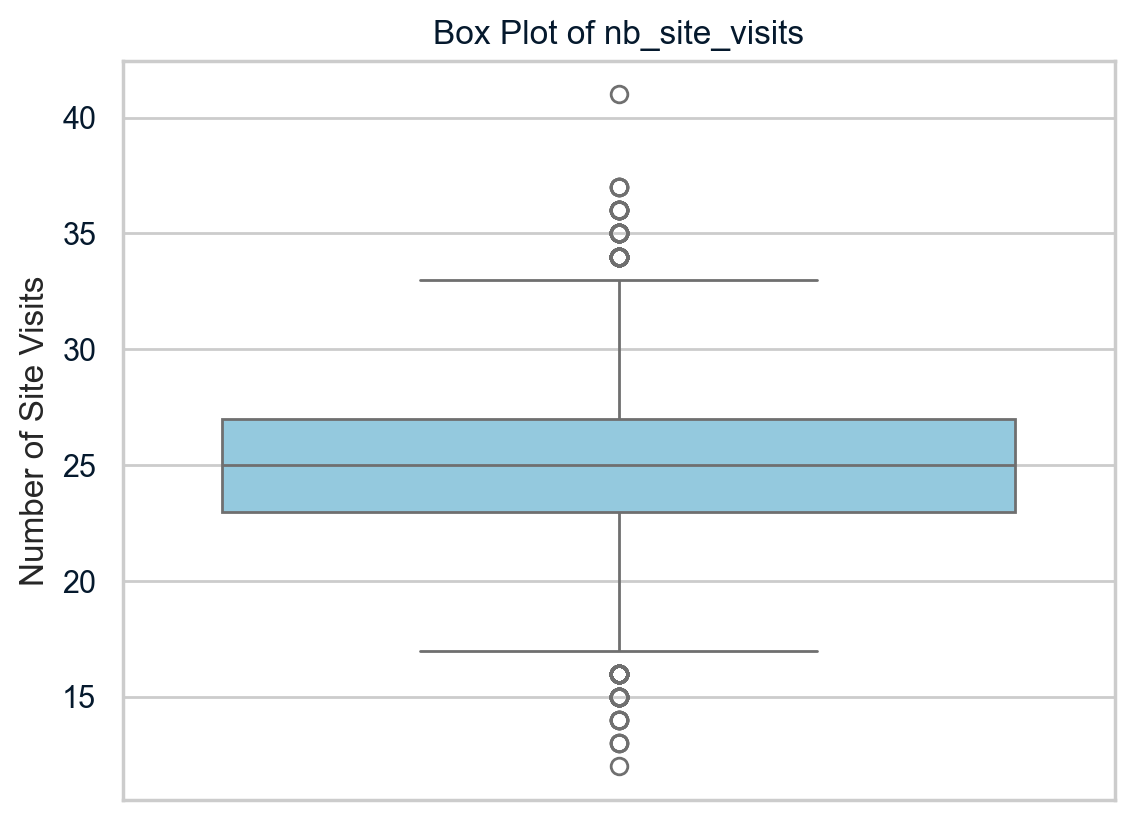

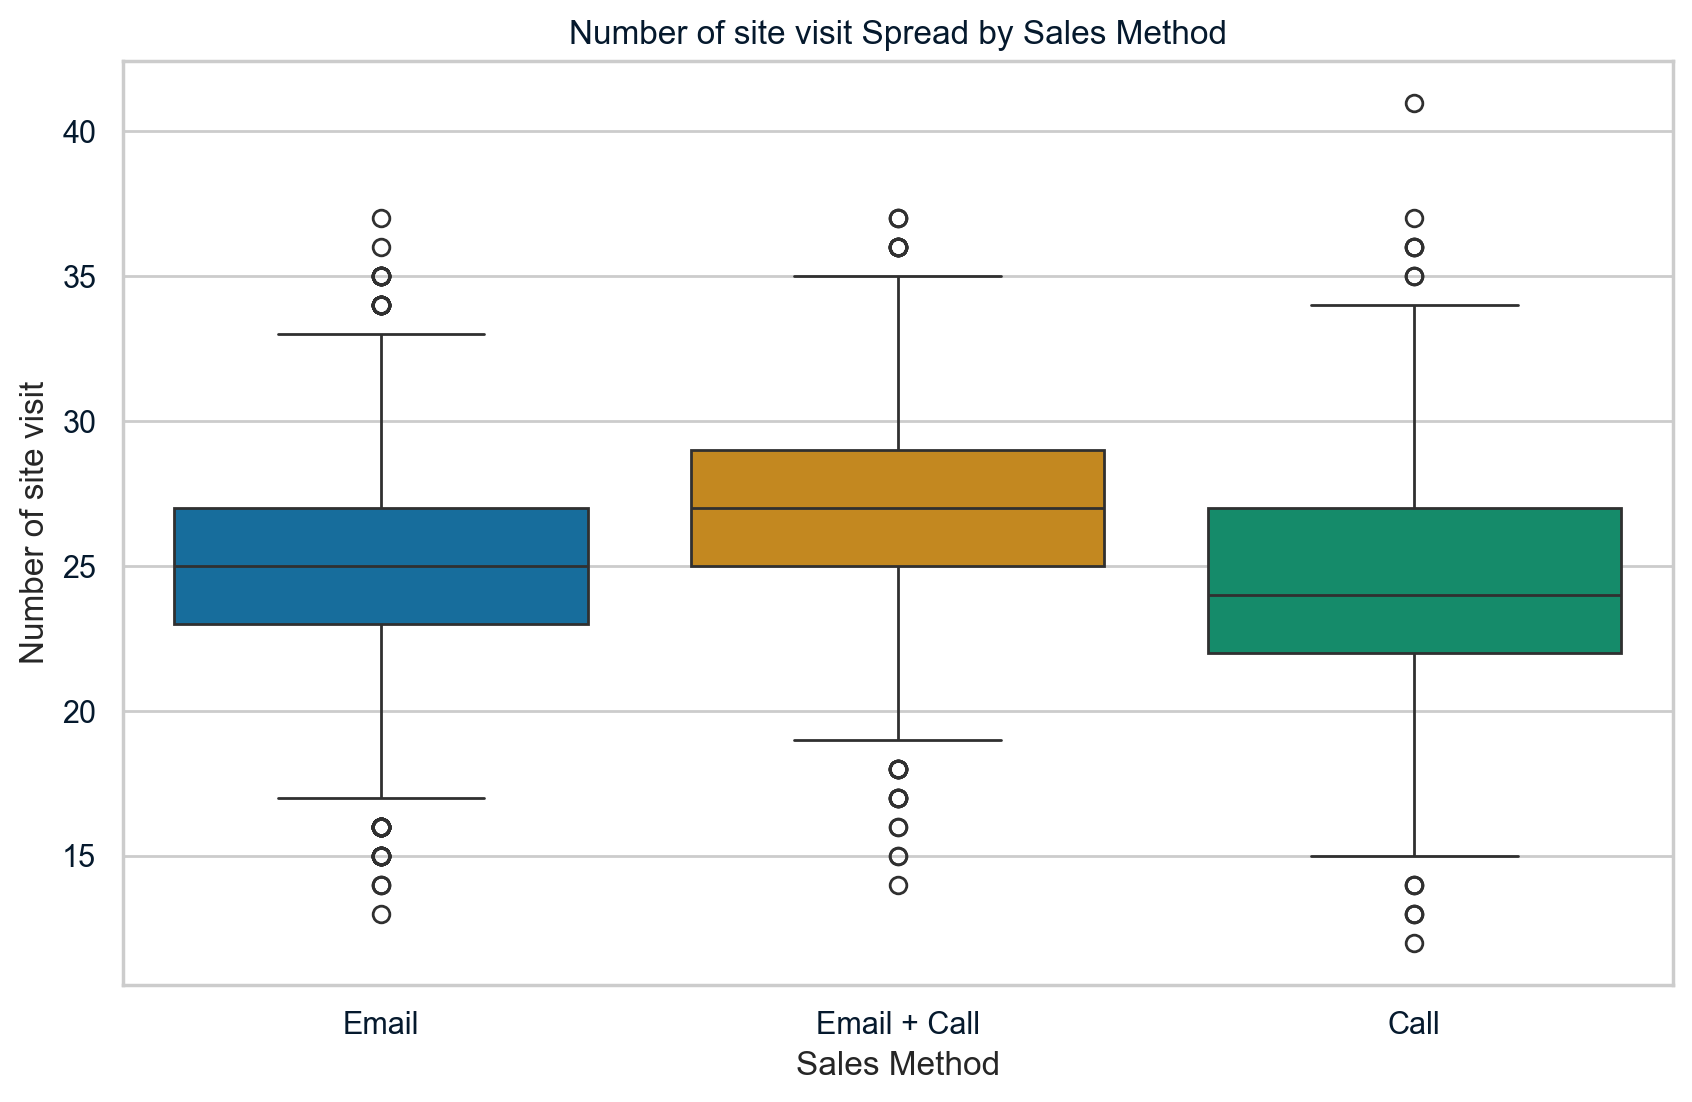

In [99]:
# Visualizing the overall number of site visits
# Overall sight visit
sns.boxplot(data=eda, y='nb_site_visits', color='skyblue')
plt.title('Box Plot of nb_site_visits')
plt.ylabel('Number of Site Visits')
plt.show()

# Sight visit per sales_method
plt.figure(figsize=(10, 6))
sns.boxplot(data=eda, x='sales_method', y='nb_site_visits', hue='sales_method', palette='colorblind')
plt.title('Number of site visit Spread by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Number of site visit')
plt.show()

In [100]:
# Counting the number of customers who visited more than 40 times
num_customers_visited_more_than_40 = len(eda[eda['nb_site_visits'] > 40])

print("Number of customers who visited more than 40 times:", num_customers_visited_more_than_40)

Number of customers who visited more than 40 times: 1


In [101]:
# Grouping the data by state and sum the revenue for each state
revenue_by_state = eda.groupby('state')['revenue'].sum().reset_index()

# Sorting the states based on their total revenue
revenue_by_state_sorted = revenue_by_state.sort_values(by='revenue', ascending=False)

# Getting the top 5 states by revenue
top_5_states_by_revenue = revenue_by_state_sorted.head(5)
print("Top 5 states by revenue:")
print(top_5_states_by_revenue)

Top 5 states by revenue:
         state    revenue
4   California  176729.57
42       Texas  114691.45
31    New York   90651.87
8      Florida   86781.53
12    Illinois   57579.82


In [102]:
# Grouping by 'state' and counting the missing values in 'revenue' column
missing_values_by_state = eda[eda.revenue_category == 'Null'].groupby('state').size().reset_index(name='missing_count').sort_values(by='missing_count', ascending=False)
missing_values_by_state

,state,missing_count
4,California,133
42,Texas,78
8,Florida,78
31,New York,66
34,Ohio,46
37,Pennsylvania,45
12,Illinois,41
21,Michigan,32
41,Tennessee,32
29,New Jersey,32


In [103]:
# Grouping by 'state' and counting missing values in 'revenue' column
missing_values_by_state = eda[eda.revenue_category == 'Null'].groupby('state').size().reset_index(name='missing_count')

# Calculating the total records for each state
total_records_by_state = eda.groupby('state').size().reset_index(name='total_count')

# Merging the two DataFrames on 'state'
state = missing_values_by_state.merge(total_records_by_state, on='state')

# Calculating percentage of missing values for each state
state['percentage_missing'] = (state.missing_count/state.total_count)*100
state.sort_values(by = 'percentage_missing',ascending = False)

,state,missing_count,total_count,percentage_missing
7,Delaware,7,34,20.588235
33,North Dakota,5,30,16.666667
1,Alaska,5,40,12.500000
3,Arkansas,14,132,10.606061
28,New Hampshire,5,53,9.433962
47,West Virginia,8,85,9.411765
41,Tennessee,32,340,9.411765
15,Kansas,13,142,9.154930
8,Florida,78,904,8.628319
20,Massachusetts,24,294,8.163265


**III. Analyzing the Business Metrics**
The Average Revenue per Customer Visit is a measure that indicates the typical revenue produced from each visit to the company's site. It aids in assessing the success of the company’s online sales approach and the benefits gained from every customer interaction on the site.

How to Utilize the Metric:

Observe Trends: Analyze the average revenue generated per customer visit over time to detect trends and patterns. Rising trends could suggest enhancements in online sales tactics or customer interaction, whereas falling trends might highlight areas needing improvement.

Benchmarking: Evaluate the average revenue per visit in relation to industry standards or competitors' results to measure the company's competitiveness and pinpoint areas that need enhancement.

Performance Assessment: Utilize the metric to assess the efficacy of marketing initiatives, website enhancements, or adjustments in sales tactics. Determine successful periods and elements leading to achievements.

In [104]:
# Initial Average Revenue per Visit
total_revenue = eda['revenue'].sum()
total_visits = eda['nb_site_visits'].sum()
average_revenue_per_visit = total_revenue / total_visits
print("Initial Average Revenue per Visit:", average_revenue_per_visit)

Initial Average Revenue per Visit: 3.824152241657151


Analyzing the different sales methods provides insights into the effectiveness of each of these in converting website visits into revenue and helps identify which sales methods are most successful in driving revenue per visit.

In [105]:
# Calculating total revenue and total visits for each sales method
total_revenue_by_method = eda.groupby('sales_method')['revenue'].sum()
total_visits_by_method = eda.groupby('sales_method')['nb_site_visits'].sum()

# Calculating the average revenue per visit for each sales method
average_revenue_per_visit_by_method = total_revenue_by_method / total_visits_by_method
print("Initial Average Revenue per Visit (by Sales Method):")
print(average_revenue_per_visit_by_method)

Initial Average Revenue per Visit (by Sales Method):
sales_method
Call            1.951001
Email           3.919088
Email + Call    6.865501
dtype: float64


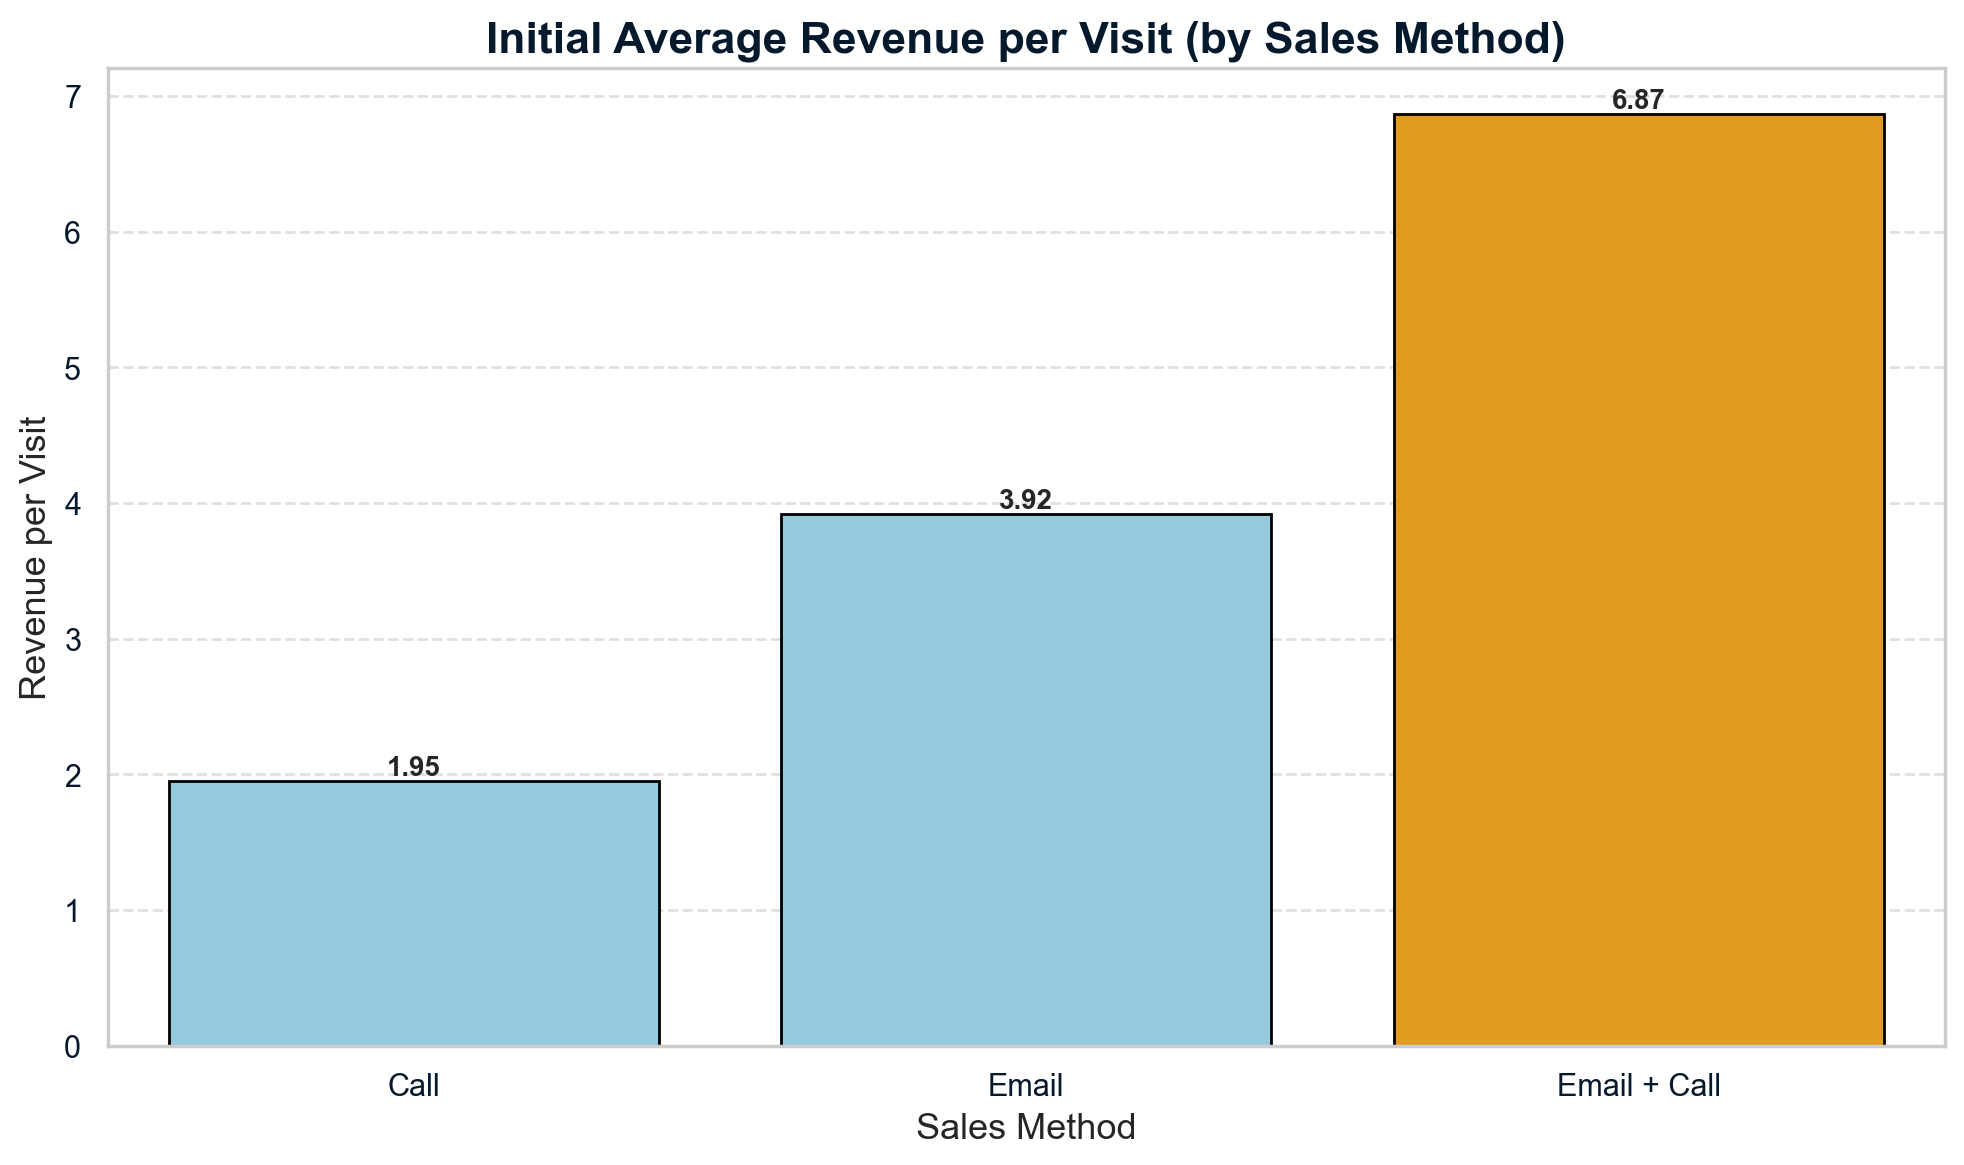

In [106]:
# Converting the Series to DataFrame
average_revenue_df = average_revenue_per_visit_by_method.reset_index()
average_revenue_df.columns = ['sales_method', 'revenue_per_visit']

# Identifying the top performer
top_idx = average_revenue_df['revenue_per_visit'].idxmax()

# Highlighting the top method in orange
bar_colors = ['skyblue' if i != top_idx else 'orange' for i in range(len(average_revenue_df))]

# Plotting
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    data=average_revenue_df,
    x='sales_method', y='revenue_per_visit',
    palette=bar_colors,
    edgecolor='black'
)

# Adding the bar value labels
for bar in barplot.patches:
    height = bar.get_height()
    barplot.annotate(f'{height:.2f}',
                     (bar.get_x() + bar.get_width() / 2, height),
                     ha='center', va='bottom',
                     fontsize=10, fontweight='bold')

# Styling the plot
plt.title('Initial Average Revenue per Visit (by Sales Method)', fontsize=16, fontweight='bold')
plt.xlabel('Sales Method', fontsize=13)
plt.ylabel('Revenue per Visit', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend([], [], frameon=False)

plt.show()

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation